# SET UP

In [1]:
import pandas as pd
import numpy as np

import pickle

from sklearn.model_selection import train_test_split

from gtda.homology.cubical import CubicalPersistence
from gtda.diagrams import PersistenceImage
from joblib import Parallel, delayed


In [2]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:

import gudhi
from gudhi import CubicalComplex
from gudhi import plot_persistence_barcode, plot_persistence_diagram


In [191]:
with open('../../data/train.pickle', 'rb') as f:
    train = pickle.load(f)

In [192]:
with open('../../data/train.pickle', 'rb') as f:
    train_o = pickle.load(f)

In [193]:
with open('../../data/test.pickle', 'rb') as f:
    test = pickle.load(f)

In [194]:
with open('../../data/test.pickle', 'rb') as f:
    test_o = pickle.load(f)

In [88]:
train

,sensor_data,label,model,velocity,mass,deceleration_average
0,"[[-5.730505819187293, 0.021809132292789083, -0...",3,Golf VI,21,1341.0,-4.874774
1,"[[-5.72556721671683, 0.0190849221728848, -0.34...",3,Golf VI,21,1341.0,-4.868881
2,"[[-5.880108022251814, 0.08222474189661085, -0....",3,Golf VI,20,1341.0,-5.098785
3,"[[-5.906634721955015, 0.059193506211250406, -0...",3,Golf VI,20,1341.0,-5.059594
4,"[[-5.474432312573297, 0.13487512855141023, -0....",3,Golf VI,20,1341.0,-4.774860
...,...,...,...,...,...,...
4048,"[[-5.324453704687594, -0.15054797322465596, -0...",4,Variant Comfortline,20,1530.0,-4.794934
4049,"[[-6.606383663551209, -0.36275289291536233, 0....",4,Variant Comfortline,20,1530.0,-5.272853
4050,"[[-5.7613776142408755, -0.29543847657441596, 0...",4,Variant Comfortline,20,1530.0,-4.844974
4051,"[[-5.357791872121975, -0.34445334501254266, 0....",4,Variant Comfortline,20,1530.0,-5.327936


In [89]:
test

,sensor_data,label,model,velocity,mass,deceleration_average
0,"[[-3.9346010604972648, -0.05542138047796165, -...",0,Variant Comfortline,30,1530.0,-3.393840
1,"[[-3.4810850496899266, 0.06682498013278597, -0...",0,Variant Comfortline,30,1530.0,-3.062394
2,"[[-3.8058791698213876, 0.059129464753241476, -...",0,Variant Comfortline,30,1530.0,-3.241874
3,"[[-3.056437445215012, -0.0169762924105487, 0.0...",0,Variant Comfortline,30,1530.0,-3.053816
4,"[[-3.183553735242826, 0.03141200276945951, -0....",0,Variant Comfortline,30,1530.0,-2.872724
...,...,...,...,...,...,...
996,"[[-5.0612570024581345, 0.23197297124025462, -0...",0,E_(Rifter_Partner),20,1870.0,-4.371684
997,"[[-4.8881258101114415, 0.03531683823514059, -0...",0,E_(Rifter_Partner),20,1870.0,-4.267343
998,"[[-3.322402727758069, -0.026600122749993734, -...",0,E_(Rifter_Partner),20,1982.0,-3.285810
999,"[[-3.297653630125864, -0.16657858961889221, -0...",0,E_(Rifter_Partner),20,1982.0,-3.119895


In [90]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4053 entries, 0 to 4052
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sensor_data           4053 non-null   object 
 1   label                 4053 non-null   int64  
 2   model                 4053 non-null   object 
 3   velocity              4053 non-null   int64  
 4   mass                  4053 non-null   float64
 5   deceleration_average  4053 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 190.1+ KB


In [91]:
train.sensor_data.iloc[0].shape

(128, 6)

In [92]:
X_train_vol = np.stack(train['sensor_data'].values, axis=0)  # (n_train, 128,2,3)

In [93]:
X_test_vol  = np.stack(test['sensor_data'].values, axis=0)   # (n_test, 128,2,3)

# Homology

In [94]:
cubical = CubicalPersistence(homology_dimensions=[0, 1], n_jobs=-1)
train_diags = cubical.fit_transform(X_train_vol)

Computing cubical persistence diagrams...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [95]:
test_diags  = cubical.transform(X_test_vol)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [96]:
pers_imager = PersistenceImage(
    sigma=1.0,
    n_bins=20,
    weight_function=None,
    n_jobs=-1
)
X_train_pers = pers_imager.fit_transform(train_diags)  


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fitting and transforming persistence images on train set...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Transforming persistence images on test set...


In [97]:
X_test_pers  = pers_imager.transform(test_diags)       

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [98]:
train = train.copy()
train['pers_image'] = list(X_train_pers)

In [99]:
test = test.copy()
test['pers_image']  = list(X_test_pers)

In [101]:
y_train = train['label'].values

In [102]:
y_test  = test['label'].values

In [104]:
X = np.stack(train['pers_image'].values)  
y = train['label'].values                  # 
classes = np.unique(y)

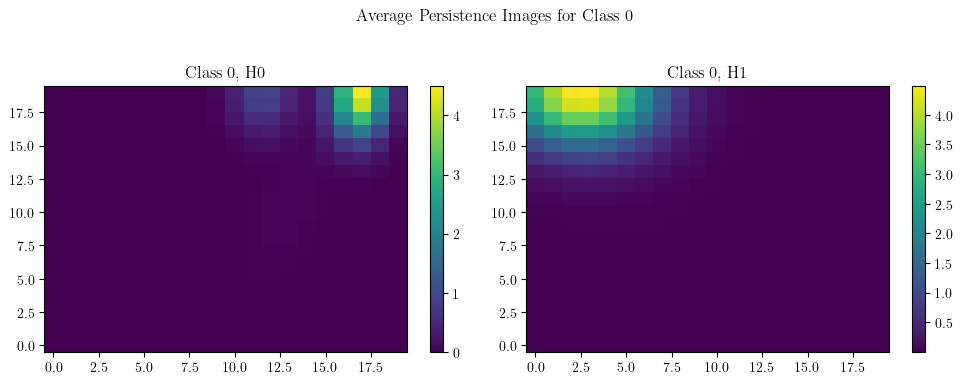

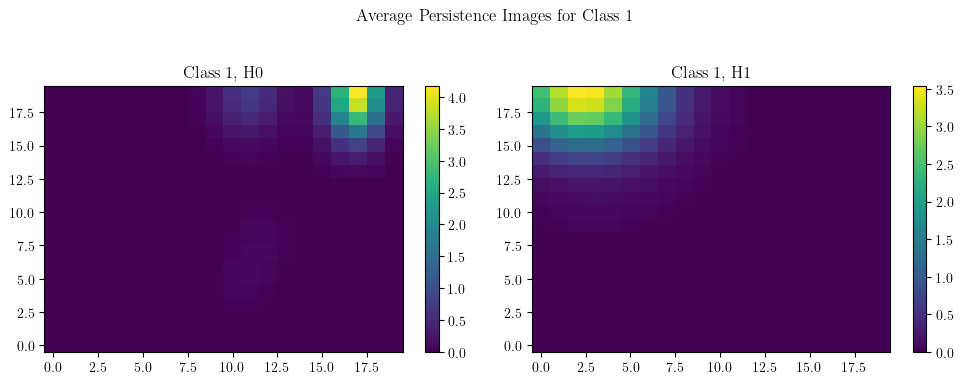

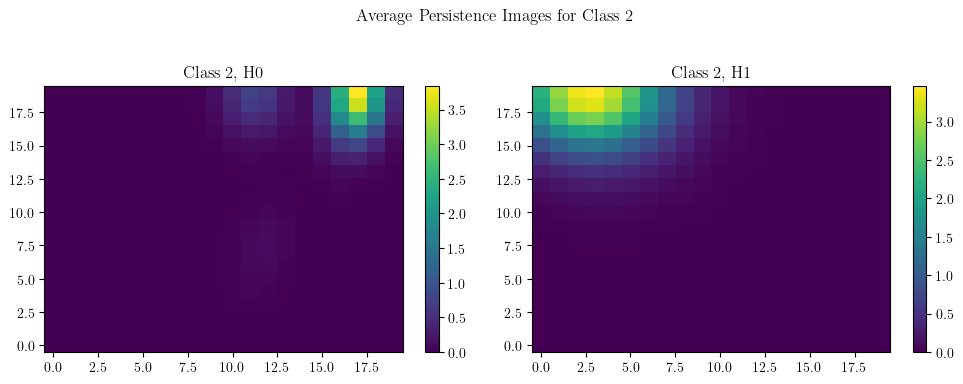

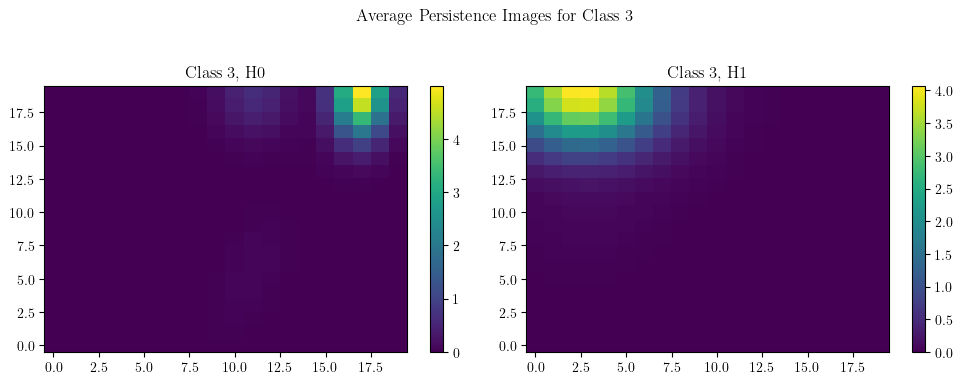

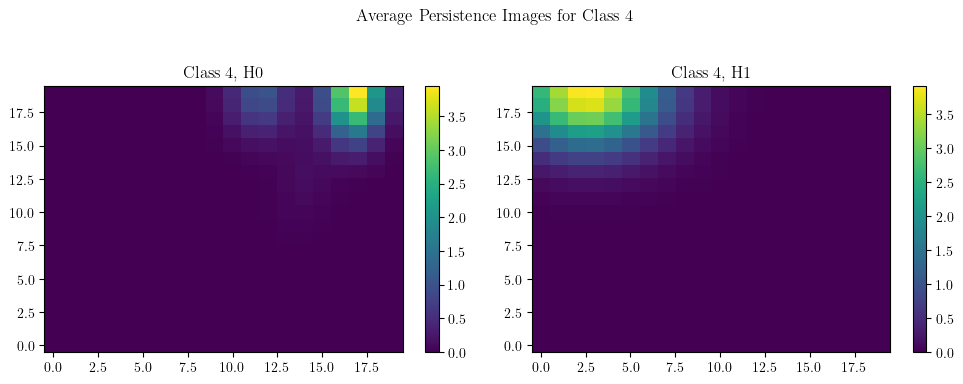

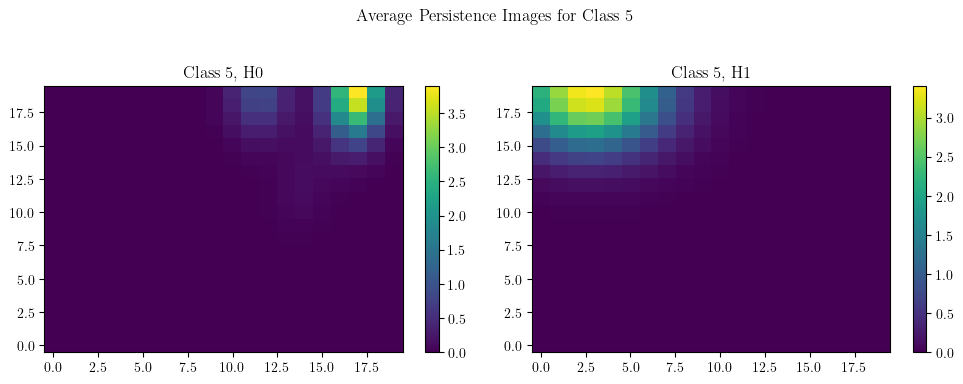

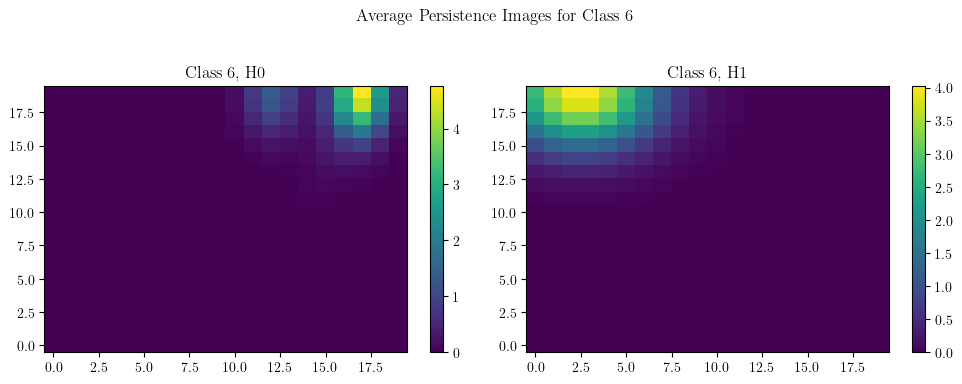

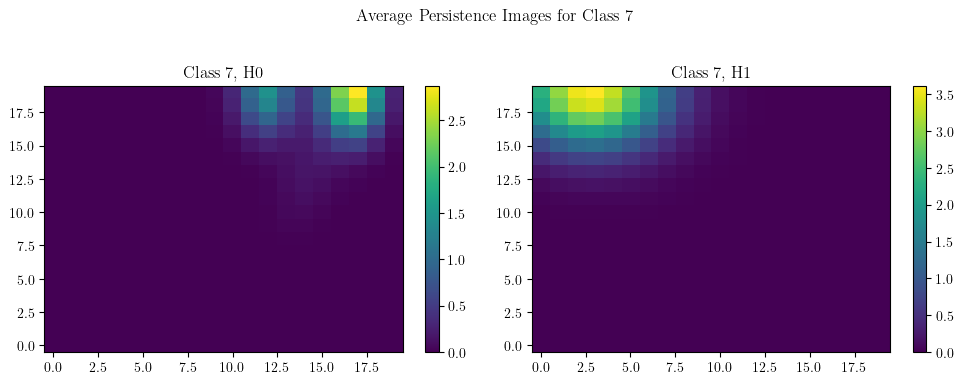

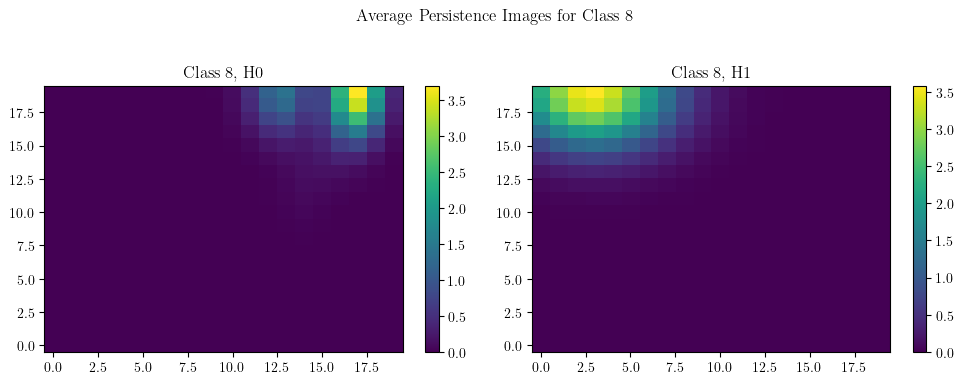

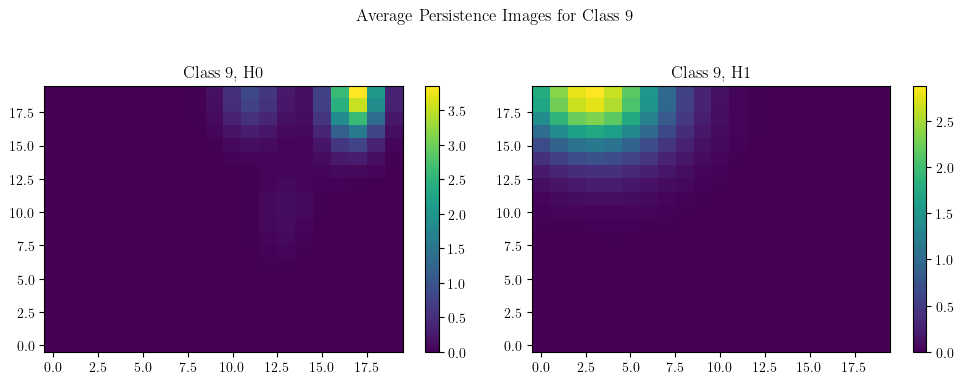

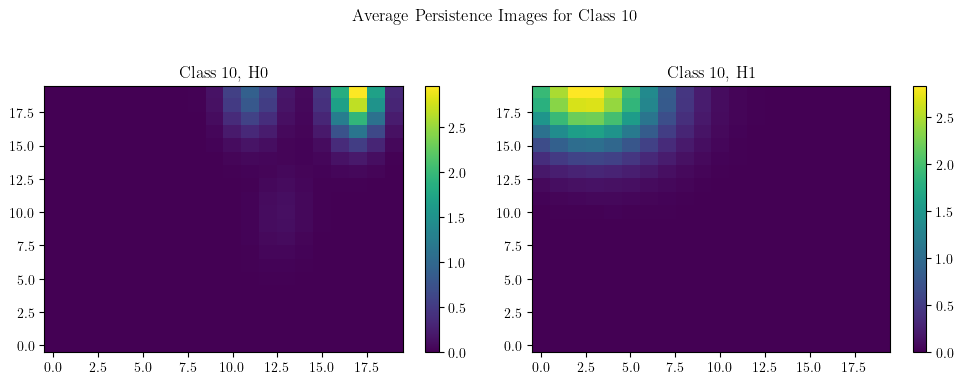

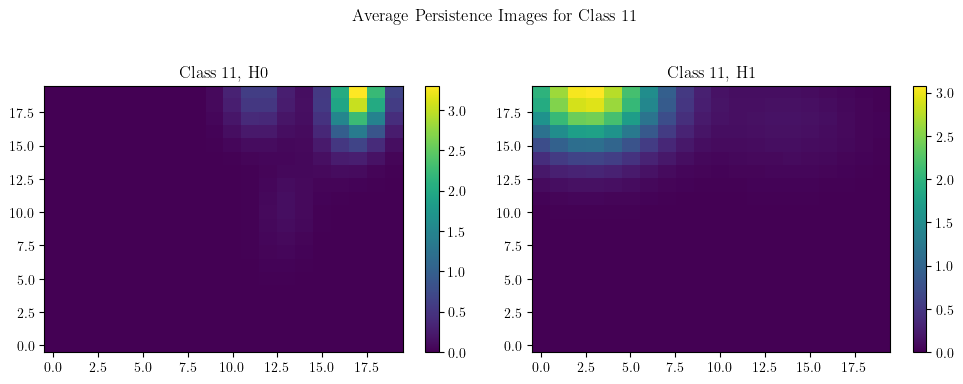

In [105]:
for cls in classes:
    cls_imgs = X[y == cls]                 # shape: (n_cls, n_dims, 20, 20)
    mean_imgs = cls_imgs.mean(axis=0)      # shape: (n_dims, 20, 20)
    n_dims = mean_imgs.shape[0]

    fig, axes = plt.subplots(1, n_dims, figsize=(5 * n_dims, 4))
    if n_dims == 1:
        axes = [axes]
    for d in range(n_dims):
        im = axes[d].imshow(mean_imgs[d], origin='lower', aspect='auto')
        axes[d].set_title(f"Class {cls}, H{d}")
        fig.colorbar(im, ax=axes[d])
    plt.suptitle(f"Average Persistence Images for Class {cls}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [106]:
n_samples, n_dims, h, w = X.shape
X_flat = X.reshape(n_samples, -1)          
pca = PCA(n_components=2)
proj = pca.fit_transform(X_flat)

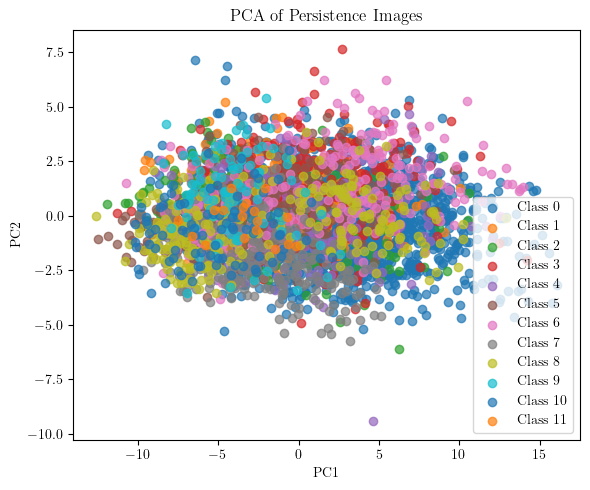

In [110]:
plt.figure(figsize=(6, 5))
for cls in classes:
    mask = (y == cls)
    plt.scatter(proj[mask, 0], proj[mask, 1], label=f"Class {cls}", alpha=0.7)
plt.title('PCA of Persistence Images')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

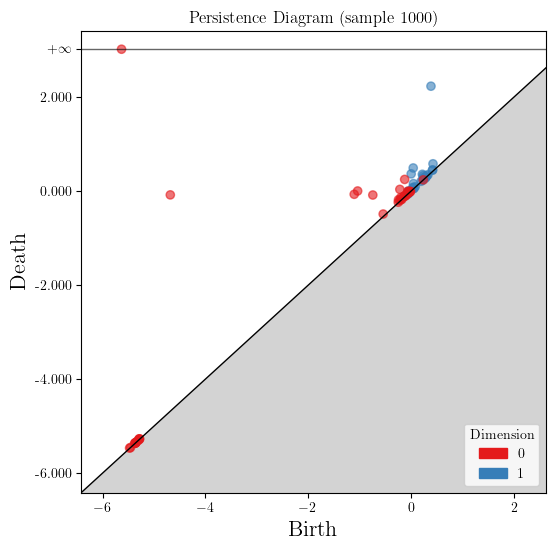

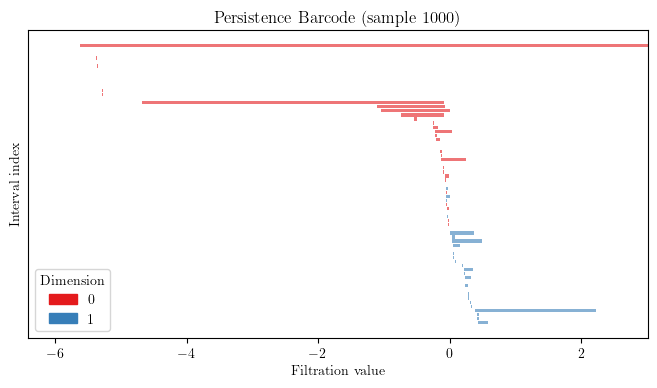

In [112]:

idx = 1_000
volume = train['sensor_data'].iloc[idx]  

# 1. Build the cubical complex and compute persistence
cc = CubicalComplex(top_dimensional_cells=volume)
cc.compute_persistence(homology_coeff_field=2, min_persistence=0.0)

# Retrieve the list of (dim, (birth, death)) pairs
diagram = cc.persistence()

# 2. Plot the persistence diagram
plt.figure(figsize=(6,6))
plot_persistence_diagram(diagram, legend=True, axes=plt.gca())
plt.title(f"Persistence Diagram (sample {idx})")
plt.show()

# 3. Plot the barcode
plt.figure(figsize=(8,4))
plot_persistence_barcode(diagram, axes=plt.gca())
plt.title(f"Persistence Barcode (sample {idx})")
plt.xlabel("Filtration value")
plt.ylabel("Interval index")
plt.show()

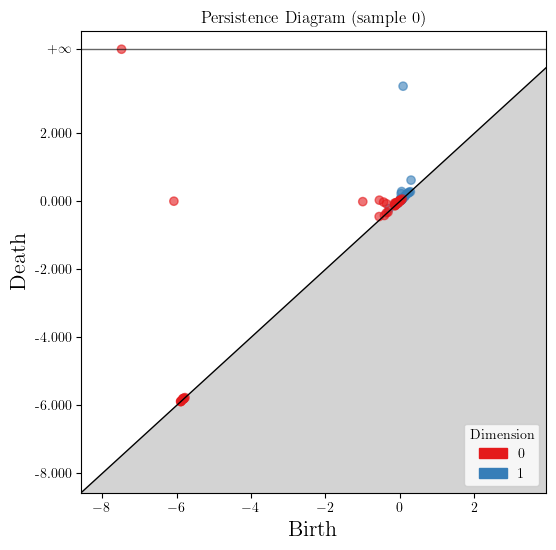

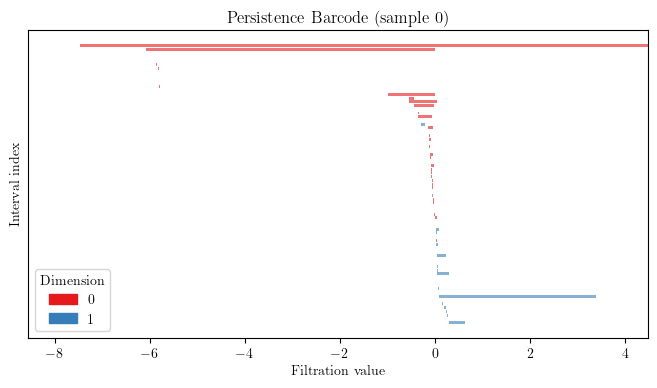

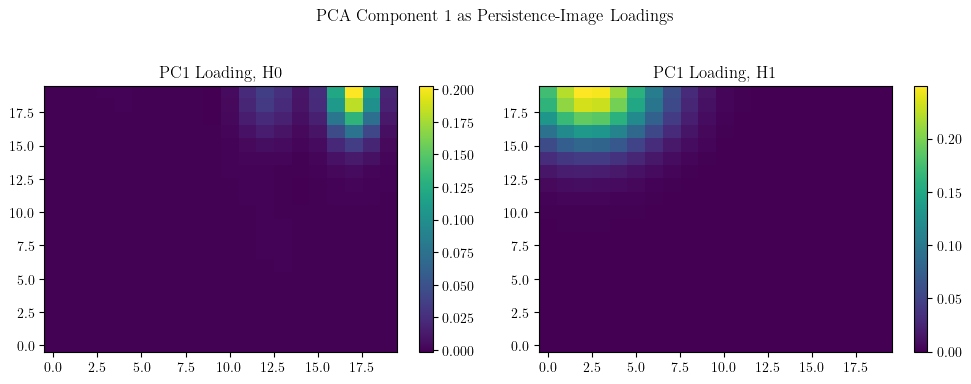

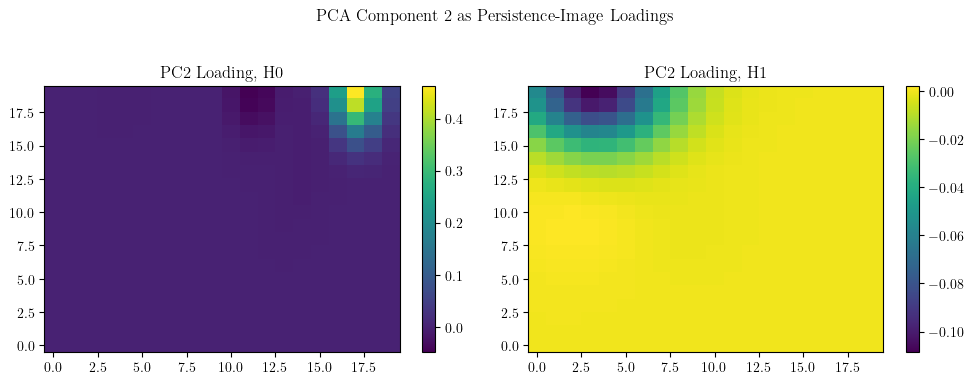

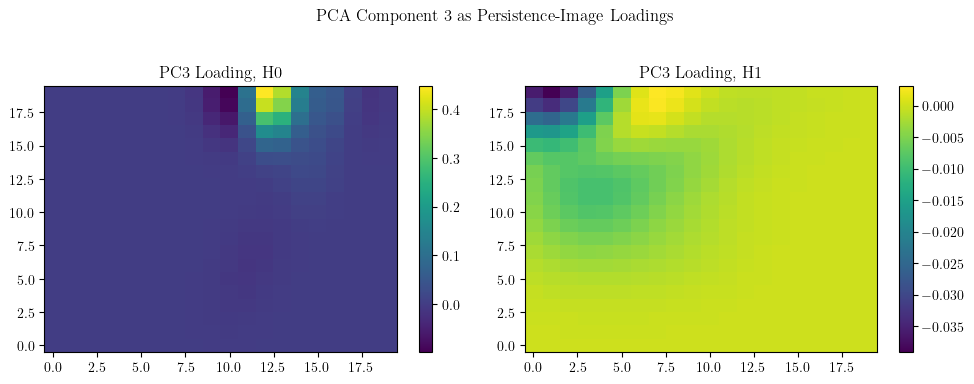

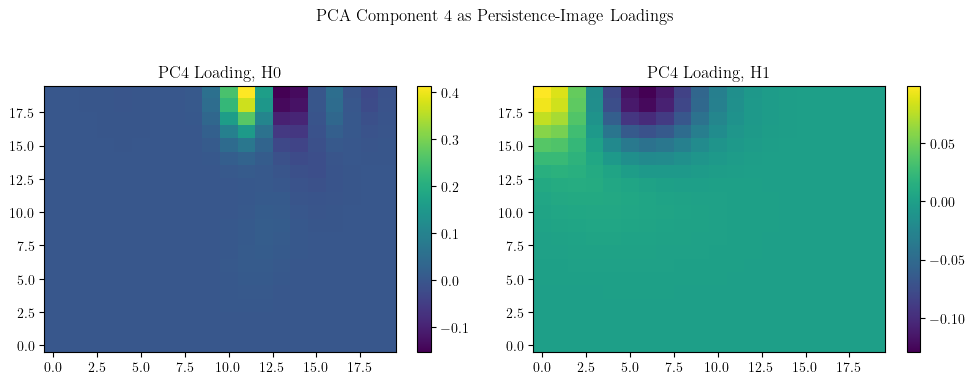

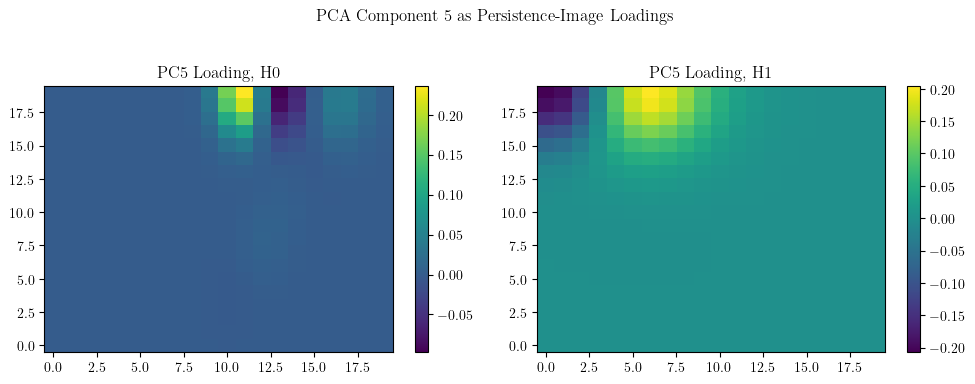

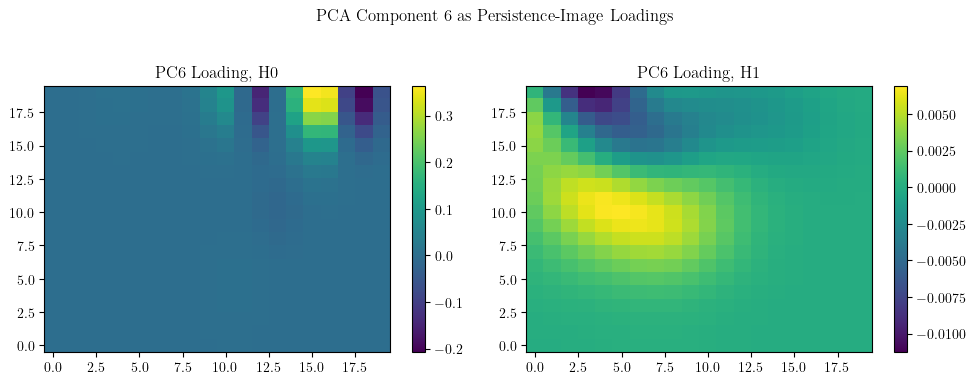

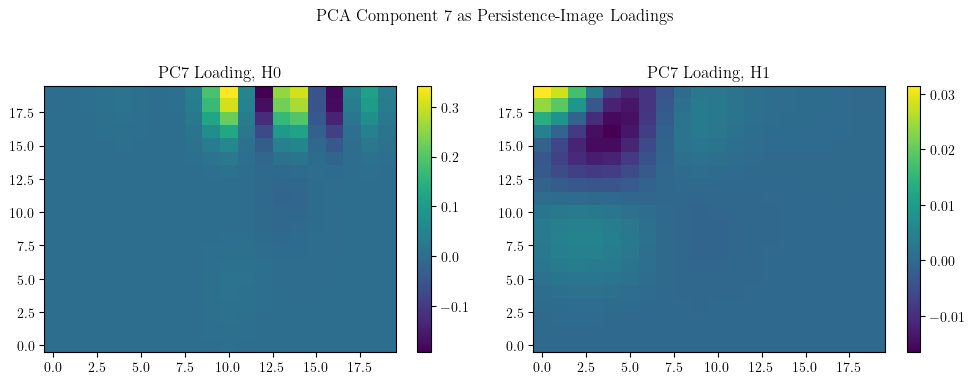

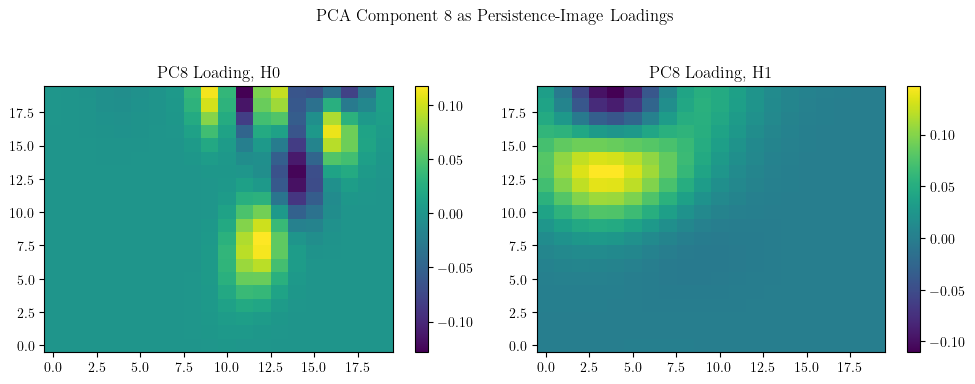

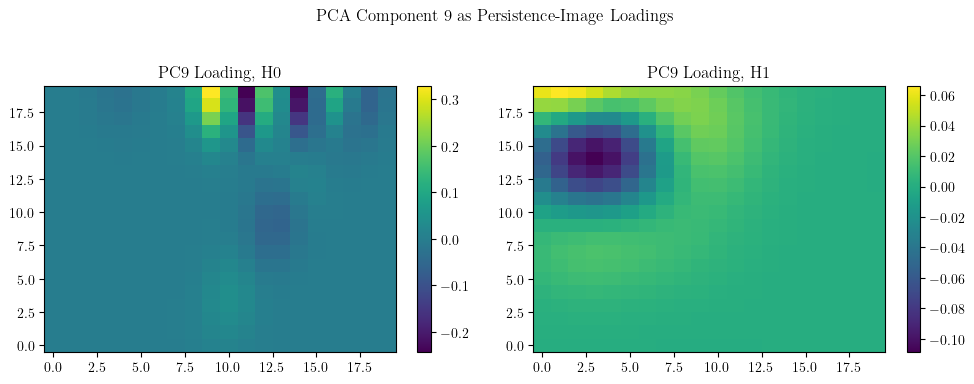

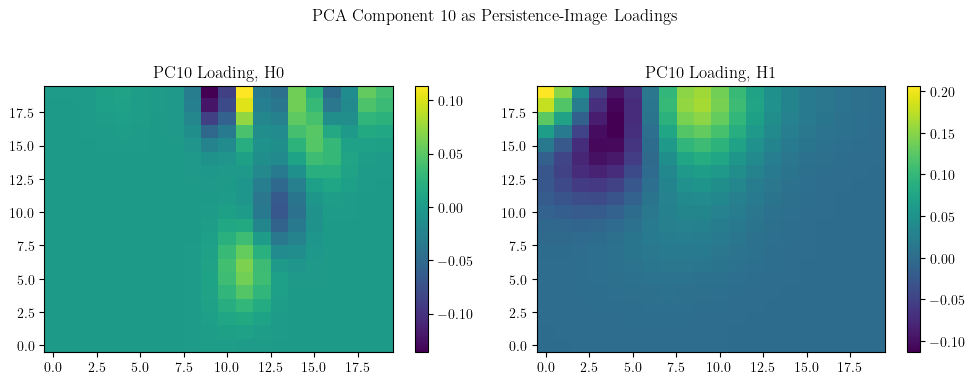

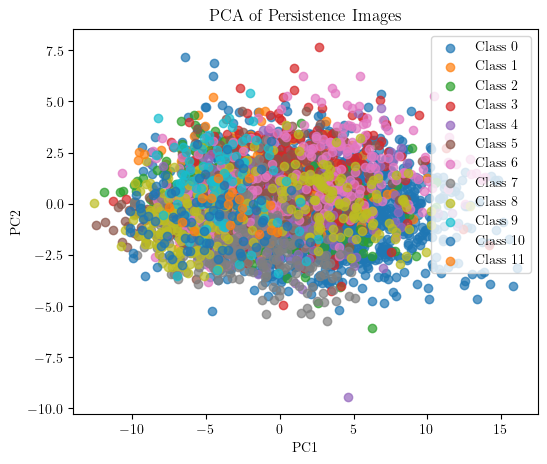

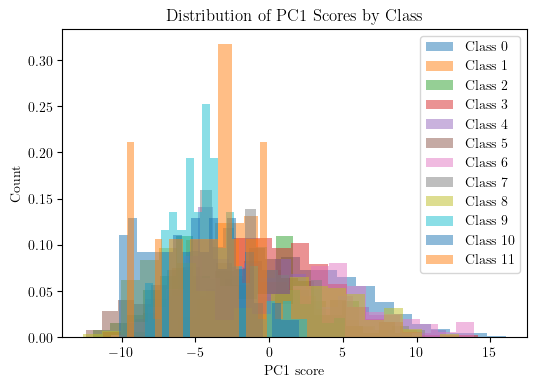

Explained variance ratios: [0.75645142 0.1079792  0.05360007 0.03189238 0.02133513 0.01052155
 0.00668859 0.00239892 0.00178769 0.0015235 ]


In [113]:


idx = 0
volume = train['sensor_data'].iloc[idx]  # shape (128,2,3)

# build cubical complex and compute persistence
cc = gudhi.CubicalComplex(top_dimensional_cells=volume)
cc.compute_persistence(homology_coeff_field=2, min_persistence=0.0)
diagram = cc.persistence()

# plot persistence diagram
plt.figure(figsize=(6,6))
plot_persistence_diagram(diagram, axes=plt.gca(), legend=True)
plt.title(f"Persistence Diagram (sample {idx})")
plt.show()

# plot barcode
plt.figure(figsize=(8,4))
plot_persistence_barcode(diagram, axes=plt.gca())
plt.title(f"Persistence Barcode (sample {idx})")
plt.xlabel("Filtration value")
plt.ylabel("Interval index")
plt.show()


# -- 2. PCA on persistence‐image features and visualize loadings --

# assume `train['pers_image']` holds arrays of shape (n_dims, 20, 20)
X = np.stack(train['pers_image'].values)   # (n_samples, n_dims, 20,20)
y = train['label'].values                  # (n_samples,)
n_samples, n_dims, h, w = X.shape

# flatten and do PCA
X_flat = X.reshape(n_samples, -1)          # (n_samples, n_dims*h*w)
pca = PCA(n_components=10)
proj = pca.fit_transform(X_flat)

# plot PC loadings as 'eigen‐images'
for comp_idx, comp in enumerate(pca.components_, start=1):
    comp_img = comp.reshape(n_dims, h, w)
    fig, axes = plt.subplots(1, n_dims, figsize=(5*n_dims,4))
    if n_dims == 1:
        axes = [axes]
    for d in range(n_dims):
        im = axes[d].imshow(comp_img[d], origin='lower', aspect='auto')
        axes[d].set_title(f"PC{comp_idx} Loading, H{d}")
        fig.colorbar(im, ax=axes[d])
    plt.suptitle(f"PCA Component {comp_idx} as Persistence-Image Loadings")
    plt.tight_layout(rect=[0,0.03,1,0.95])
    plt.show()

# scatter in PC1 vs PC2 colored by class
plt.figure(figsize=(6,5))
for cls in np.unique(y):
    mask = (y == cls)
    plt.scatter(proj[mask,0], proj[mask,1], label=f"Class {cls}", alpha=0.7)
plt.title("PCA of Persistence Images")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# histogram of PC1 scores by class
plt.figure(figsize=(6,4))
for cls in np.unique(y):
    mask = (y == cls)
    plt.hist(proj[mask,0], bins=20, alpha=0.5, label=f"Class {cls}", density=True)
plt.title("Distribution of PC1 Scores by Class")
plt.xlabel("PC1 score")
plt.ylabel("Count")
plt.legend()
plt.show()

# print explained variance
print("Explained variance ratios:", pca.explained_variance_ratio_)

In [127]:
X_test = np.stack(test['pers_image'].values)   
y_test = test['label'].values                  
n_samples, n_dims, h, w = X_test.shape

X_flat_test = X_test.reshape(n_samples, -1)         
proj_test = pca.transform(X_flat_test)


# Actual preproc

In [232]:
pca

PCA(n_components=10)

In [128]:
proj_test.shape

(1001, 10)

In [131]:
train = train.join(pd.DataFrame(proj, columns=[f'PCA_{i}' for i in range(10)]))

In [132]:
test = test.join(pd.DataFrame(proj_test, columns=[f'PCA_{i}' for i in range(10)]))

In [133]:
test

,sensor_data,label,model,velocity,mass,deceleration_average,pers_image,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9
0,"[[-3.9346010604972648, -0.05542138047796165, -...",0,Variant Comfortline,30,1530.0,-3.393840,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",2.848093,2.959809,-1.512063,-0.728800,-1.363373,-0.308561,-0.104881,-0.310296,-0.013774,0.199116
1,"[[-3.4810850496899266, 0.06682498013278597, -0...",0,Variant Comfortline,30,1530.0,-3.062394,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",-0.240603,2.659239,-1.035216,-0.962135,-1.268155,0.135290,0.214349,-0.482570,-0.219961,0.146214
2,"[[-3.8058791698213876, 0.059129464753241476, -...",0,Variant Comfortline,30,1530.0,-3.241874,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",2.309261,2.947249,-1.328314,-1.461261,-0.268298,0.322653,-0.122232,-0.607933,-0.088061,0.062982
3,"[[-3.056437445215012, -0.0169762924105487, 0.0...",0,Variant Comfortline,30,1530.0,-3.053816,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",1.653889,1.527026,-1.749056,-0.613812,-1.720542,-0.153148,-0.171938,-0.433245,-0.021749,0.152165
4,"[[-3.183553735242826, 0.03141200276945951, -0....",0,Variant Comfortline,30,1530.0,-2.872724,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",0.502683,3.036699,-1.042042,-1.143940,-0.925411,0.153711,0.184763,-0.467716,-0.208107,0.169644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,"[[-5.0612570024581345, 0.23197297124025462, -0...",0,E_(Rifter_Partner),20,1870.0,-4.371684,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.1...",-8.878610,0.021569,0.226193,-0.373346,-0.337561,0.229617,-0.351593,0.302590,-0.201331,-0.147483
997,"[[-4.8881258101114415, 0.03531683823514059, -0...",0,E_(Rifter_Partner),20,1870.0,-4.267343,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.3...",-6.897603,1.107228,1.027044,0.580663,-0.938972,-0.757111,-0.056781,0.034906,0.066082,0.053398
998,"[[-3.322402727758069, -0.026600122749993734, -...",0,E_(Rifter_Partner),20,1982.0,-3.285810,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",-7.485093,0.244104,-0.205604,-0.805307,-1.726852,1.032448,0.336753,-0.217172,-0.554011,-0.058891
999,"[[-3.297653630125864, -0.16657858961889221, -0...",0,E_(Rifter_Partner),20,1982.0,-3.119895,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",-5.636693,-1.209156,-0.299473,-0.813937,-2.234650,1.116533,0.503174,-0.110409,-0.679229,0.013320


In [134]:
X_train_vol = np.stack(train['sensor_data'].values, axis=0)  # (n_train, 128,2,3)
X_test_vol  = np.stack(test['sensor_data'].values, axis=0)   # (n_test, 128,2,3)

In [135]:
sensor_data_mean = X_train_vol.mean(axis=0)

In [136]:
sensor_data_std = X_train_vol.std(axis=0)

In [137]:
sensor_data_std.shape

(128, 6)

In [138]:
train.sensor_data = train.sensor_data.apply(lambda x: (x - sensor_data_mean)/sensor_data_std)

In [139]:
test.sensor_data = test.sensor_data.apply(lambda x: (x - sensor_data_mean)/sensor_data_std)

In [140]:
X_train_vol = np.stack(train['pers_image'].values, axis=0)  # (n_train, 128,2,3)
X_test_vol  = np.stack(test['pers_image'].values, axis=0)   # (n_test, 128,2,3)

In [141]:
pers_mean = X_train_vol.mean(axis=0)

In [142]:
pers_std = X_train_vol.std(axis=0)

In [143]:
sensor_data_std.shape

(128, 6)

In [144]:
train.pers_image = train.pers_image.apply(lambda x: (x - pers_mean)/(pers_std + 1e-6))

In [145]:
test.pers_image = test.pers_image.apply(lambda x: (x - pers_mean)/(pers_std + 1e-6))

In [202]:
flat_cols = ['velocity', 'mass', 'deceleration_average'] + [f'PCA_{i}' for i in range(10)]
flat_cols

['velocity',
 'mass',
 'deceleration_average',
 'PCA_0',
 'PCA_1',
 'PCA_2',
 'PCA_3',
 'PCA_4',
 'PCA_5',
 'PCA_6',
 'PCA_7',
 'PCA_8',
 'PCA_9']

In [147]:
flat_mean = train[flat_cols].mean()

In [148]:
flat_mean

velocity                2.000074e+01
mass                    1.431586e+03
deceleration_average   -4.965903e+00
PCA_0                   8.302814e-15
PCA_1                   5.297952e-15
PCA_2                   3.779744e-15
PCA_3                  -8.415014e-16
PCA_4                   3.730656e-15
PCA_5                   3.912981e-15
PCA_6                  -3.682445e-15
PCA_7                  -1.581321e-15
PCA_8                   3.317356e-15
PCA_9                   7.520919e-16
dtype: float64

In [149]:
flat_std = train[flat_cols].std()

In [150]:
flat_std

velocity                  1.487775
mass                    116.758191
deceleration_average      0.571442
PCA_0                     4.853772
PCA_1                     1.833829
PCA_2                     1.292027
PCA_3                     0.996626
PCA_4                     0.815148
PCA_5                     0.572438
PCA_6                     0.456411
PCA_7                     0.273336
PCA_8                     0.235958
PCA_9                     0.217826
dtype: float64

In [151]:
train[flat_cols] = (train[flat_cols] - flat_mean.values)/flat_std

In [152]:
test[flat_cols] = (test[flat_cols] - flat_mean.values)/flat_std

In [153]:
train.describe()

,label,velocity,mass,deceleration_average,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9
count,4053.000000,4.053000e+03,4.053000e+03,4.053000e+03,4053.000000,4.053000e+03,4.053000e+03,4.053000e+03,4.053000e+03,4.053000e+03,4.053000e+03,4.053000e+03,4.053000e+03,4.053000e+03
mean,2.764372,-1.004542e-15,-3.927006e-16,-2.945255e-16,0.000000,-1.402502e-17,1.402502e-17,4.207507e-17,-7.012512e-18,7.012512e-18,-2.454379e-17,-2.805005e-17,-2.805005e-17,-3.155630e-17
std,3.162901,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,0.000000,-1.344339e+01,-7.758469e-01,-3.486948e+00,-2.596134,-5.139187e+00,-2.168520e+00,-6.120134e+00,-2.939821e+00,-2.435269e+00,-2.440498e+00,-3.397795e+00,-1.278950e+01,-4.135711e+00
25%,0.000000,-4.975164e-04,-7.758469e-01,-6.692529e-01,-0.755476,-6.542156e-01,-7.766979e-01,-6.204609e-01,-6.732195e-01,-7.323198e-01,-6.400747e-01,-6.820702e-01,-6.399680e-01,-6.292750e-01
50%,1.000000,-4.975164e-04,-7.758469e-01,1.530214e-02,-0.058165,-1.528477e-02,-2.144924e-01,2.282708e-02,-5.875955e-02,-1.684809e-01,-2.565918e-01,-1.082295e-01,-3.910119e-02,-1.097404e-01
75%,5.000000,-4.975164e-04,1.391025e+00,6.316796e-01,0.702564,6.534352e-01,7.471307e-01,6.365181e-01,5.993390e-01,5.743319e-01,3.989619e-01,6.387979e-01,5.136797e-01,5.274002e-01
max,11.000000,2.688081e+00,1.391025e+00,8.530399e+00,3.310964,4.184964e+00,3.466751e+00,3.192445e+00,5.463197e+00,7.820228e+00,1.056316e+01,5.617625e+00,5.926227e+00,5.462942e+00


In [163]:
test.mass = test.mass.fillna(0)

In [164]:
initial_feature_cols = ['sensor_data',
                        'velocity',
                        'mass',
                        'deceleration_average']

extended_feature_cols = initial_feature_cols + ['pers_image'] + [f'PCA_{i}' for i in range(10)]

In [165]:
initial_feature_cols

['sensor_data', 'velocity', 'mass', 'deceleration_average']

In [166]:
extended_feature_cols

['sensor_data',
 'velocity',
 'mass',
 'deceleration_average',
 'pers_image',
 'PCA_0',
 'PCA_1',
 'PCA_2',
 'PCA_3',
 'PCA_4',
 'PCA_5',
 'PCA_6',
 'PCA_7',
 'PCA_8',
 'PCA_9']

In [167]:
X_train = train[initial_feature_cols]
X_ext_train = train[extended_feature_cols]

In [168]:
X_test = test[initial_feature_cols]
X_ext_test = test[extended_feature_cols]

In [169]:
y_train = train.label

In [170]:
y_test = test.label

In [171]:
X_ttrain, X_val, X_ext_ttrain, X_ext_val, y_ttrain, y_val = train_test_split(X_train,
                                                                             X_ext_train,
                                                                             y_train,
                                                                             train_size=0.7,
                                                                             stratify=y_train)

In [172]:
X_ttrain.shape, X_val.shape, X_ext_ttrain.shape, X_ext_val.shape, y_ttrain.shape, y_val.shape

((2837, 4), (1216, 4), (2837, 15), (1216, 15), (2837,), (1216,))

<Axes: >

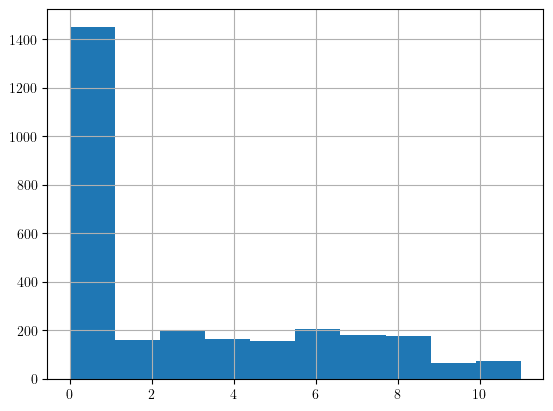

In [173]:
y_ttrain.hist()

<Axes: >

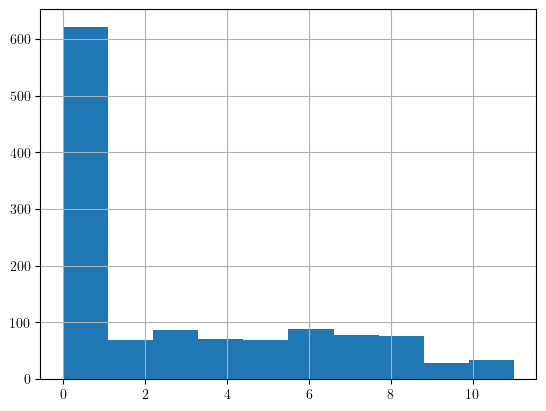

In [174]:
y_val.hist()

In [180]:
with open('../../data/transfromers_2.0/cubical.pickle', 'wb') as f:
    pickle.dump(cubical, f)
with open('../../data/transfromers_2.0/pers_imager.pickle', 'wb') as f:
    pickle.dump(pers_imager, f)


with open('../../data/transfromers_2.0/sensor_data_mean.pickle', 'wb') as f:
    pickle.dump(sensor_data_mean, f)   
with open('../../data/transfromers_2.0/sensor_data_std.pickle', 'wb') as f:
    pickle.dump(sensor_data_std, f)   


with open('../../data/transfromers_2.0/pers_mean.pickle', 'wb') as f:
    pickle.dump(pers_mean, f)   
with open('../../data/transfromers_2.0/pers_std.pickle', 'wb') as f:
    pickle.dump(pers_std, f)
    
with open('../../data/transfromers_2.0/flat_mean.pickle', 'wb') as f:
    pickle.dump(flat_mean, f)   
with open('../../data/transfromers_2.0/flat_std.pickle', 'wb') as f:
    pickle.dump(flat_std, f)   


In [181]:
clf

RandomForestClassifier(max_depth=30)

In [182]:
y_pred = clf.predict(proj_test)
y_pred_prob = clf.predict_proba(proj_test)

In [183]:
accuracy_score(y_test, y_pred)

0.43356643356643354

In [184]:
confusion_matrix(y_test != 0, y_pred != 0, normalize='true')

array([[0.67790894, 0.32209106],
       [0.63480392, 0.36519608]])

In [185]:
y_pred_prob.shape

(1001, 12)

In [186]:
y_test.shape

(1001,)

In [187]:
y_test

0       0
1       0
2       0
3       0
4       0
       ..
996     0
997     0
998     0
999     0
1000    0
Name: label, Length: 1001, dtype: int64

In [188]:
X_test.isna().sum().sum()

0

In [189]:
X_ext_test.isna().sum().sum()

0

In [231]:
X_train_v

,sensor_data,velocity,mass,deceleration_average,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9
0,"[[-0.28072790806722514, 0.48853950707154553, -...",0.671647,-0.775847,0.159472,-0.134221,9.147446,-0.885644,-6.769227,-0.277821,5.944708,-3.382837,-2.451917,12.495703,-2.957507
1,"[[-0.2718687183472922, 0.4784524841297032, -1....",0.671647,-0.775847,0.169783,-0.143415,9.382687,-1.189180,-6.807523,-0.403408,6.465598,-5.519995,-1.294239,12.417946,-6.891938
2,"[[-0.5490941730977201, 0.7122423836105083, -0....",-0.000498,-0.775847,-0.232540,-0.126038,8.199822,-1.103407,-5.968452,-0.359997,5.832278,-5.471272,-1.364844,10.369595,-7.745467
3,"[[-0.5966795105934758, 0.626963865246671, -0.9...",-0.000498,-0.775847,-0.163957,-0.135204,9.172073,-1.244052,-6.743035,-0.340863,6.229659,-5.785958,-1.387646,11.420325,-6.942922
4,"[[0.17863357950138756, 0.9071927122226388, -0....",-0.000498,-0.775847,0.334316,-0.068275,5.606525,-0.689091,-3.803956,-0.335924,3.693691,-3.449146,-0.450179,7.097578,-5.046237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4048,"[[0.447675064240758, -0.14965284998683553, 0.2...",-0.000498,0.842883,0.299188,-0.076257,6.388700,-0.016572,-4.576358,-0.015276,5.137937,-1.228812,-5.409343,6.361930,-3.532914
4049,"[[-1.8519351556873027, -0.9353910269550553, 1....",-0.000498,0.842883,-0.537150,-0.073120,6.694053,0.064385,-5.324516,0.403650,5.065831,-0.089125,-7.864124,5.165280,0.621521
4050,"[[-0.3361077632003991, -0.6861437104625557, 0....",-0.000498,0.842883,0.211620,-0.084539,6.136496,0.053944,-4.720421,0.232010,5.272375,-1.187046,-6.929561,4.657458,-3.518999
4051,"[[0.3878708682192083, -0.8676326854921836, 2.1...",-0.000498,0.842883,-0.633544,-0.046219,5.603639,0.255246,-4.077344,0.209250,4.756082,-0.638549,-5.797208,4.527033,-1.759305


In [226]:
X_ext_train

,sensor_data,velocity,mass,deceleration_average,pers_image,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9
0,"[[-0.28072790806722514, 0.48853950707154553, -...",0.671647,-0.775847,0.159472,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",0.125385,1.245574,1.067122,0.871628,-1.044507,-1.386314,-0.072213,1.186151,0.409863,0.267901
1,"[[-0.2718687183472922, 0.4784524841297032, -1....",0.671647,-0.775847,0.169783,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",0.386891,2.581249,1.607560,0.955609,-0.127401,-1.316814,-0.135856,1.165788,0.345084,-0.159023
2,"[[-0.5490941730977201, 0.7122423836105083, -0....",-0.000498,-0.775847,-0.232540,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",0.361358,1.164561,-0.493627,1.585966,-0.108352,-0.726434,0.777122,0.274905,-0.911691,0.303875
3,"[[-0.5966795105934758, 0.626963865246671, -0.9...",-0.000498,-0.775847,-0.163957,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",0.638230,1.426441,-0.760074,1.181461,-0.655522,-0.644121,0.467727,0.261748,-0.805615,0.399038
4,"[[0.17863357950138756, 0.9071927122226388, -0....",-0.000498,-0.775847,0.334316,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",-0.103056,1.827226,-1.149539,-0.062939,-1.750605,-0.428920,-0.413339,0.877638,-0.646565,0.344640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4048,"[[0.447675064240758, -0.14965284998683553, 0.2...",-0.000498,0.842883,0.299188,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",-0.309088,0.923186,-0.440106,-0.011253,-0.227793,-1.042587,0.049673,-1.328151,0.225990,1.098315
4049,"[[-1.8519351556873027, -0.9353910269550553, 1....",-0.000498,0.842883,-0.537150,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",-0.811090,-0.465060,-1.092010,-0.678854,-0.126287,0.194282,0.445340,-1.435752,1.531181,0.220183
4050,"[[-0.3361077632003991, -0.6861437104625557, 0....",-0.000498,0.842883,0.211620,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",-1.278764,-0.388140,0.355131,-0.995742,0.982699,-1.331002,-0.233202,-0.361379,1.023820,2.561940
4051,"[[0.3878708682192083, -0.8676326854921836, 2.1...",-0.000498,0.842883,-0.633544,"[[[0.0, 0.0, 0.0, 0.0, 0.0, -0.037736206799955...",-1.762622,0.355151,-0.746807,-0.832978,-0.165820,-1.013509,-0.278845,-0.811538,0.412224,1.769803


In [228]:
flat_mean

velocity                2.000074e+01
mass                    1.431586e+03
deceleration_average   -4.965903e+00
PCA_0                   8.302814e-15
PCA_1                   5.297952e-15
PCA_2                   3.779744e-15
PCA_3                  -8.415014e-16
PCA_4                   3.730656e-15
PCA_5                   3.912981e-15
PCA_6                  -3.682445e-15
PCA_7                  -1.581321e-15
PCA_8                   3.317356e-15
PCA_9                   7.520919e-16
dtype: float64